# Computing Aquisition Parameters Statistics

### Initialization

In [10]:
%load_ext autoreload
%autoreload 2


from config.settings_data import DataSetsSettings

profile = "default"
settings = DataSetsSettings.build(profile)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### kVp Statistics

In [11]:
from utils.database_statistics import summarize_image_acquisition, print_image_acquisition_summary

general_stat = summarize_image_acquisition(
    db_path=settings.DB_name
)


print_image_acquisition_summary(general_stat)


IMAGE ACQUISITION SUMMARY

Total number of images: 80,389

View counts
------------------------------------------------------------
   AP:   31,443 ( 39.1%)
   PA:   20,452 ( 25.4%)

kVp counts
------------------------------------------------------------
           <90:    1,873 (  2.3%)
           =90:   16,324 ( 20.3%)
  >90 and <120:   18,558 ( 23.1%)
          =120:   31,661 ( 39.4%)
          >120:      310 (  0.4%)
       missing:   11,663 ( 14.5%)

kVp counts by view
------------------------------------------------------------

View: AP
Total: 31,443
             <90:    1,854 (  5.9%)
             =90:   16,309 ( 51.9%)
    >90 and <120:    4,978 ( 15.8%)
            =120:       91 (  0.3%)
            >120:       32 (  0.1%)
         missing:    8,179 ( 26.0%)

View: PA
Total: 20,452
             <90:       19 (  0.1%)
             =90:       15 (  0.1%)
    >90 and <120:   13,529 ( 66.2%)
            =120:    6,768 ( 33.1%)
            >120:       83 (  0.4%)
         missing

### View Statistics

In [12]:
from utils.database_statistics import get_view_counts, print_view_counts

view_counts = get_view_counts(settings.DB_name)
print_view_counts(view_counts)




Image counts by view type
----------------------------------------
          AP:    31443 images ( 39.11%)
          PA:    20452 images ( 25.44%)
     LATERAL:    17578 images ( 21.87%)
          LL:     7507 images (  9.34%)
     missing:     3409 images (  4.24%)
----------------------------------------
       total:    80389 images


### Detector type statistics

In [13]:
from utils.database_statistics import get_detector_type_counts, print_detector_type_counts

detector_type_counts = get_detector_type_counts(settings.DB_name)
print_detector_type_counts(detector_type_counts)



Detector type counts:
detector_type_code  image_count
            DIRECT        62611
      SCINTILLATOR        14254
           missing         3524


### Aquisition parameters statistics: all views

In [14]:
from utils.database_statistics import get_kvp_by_detector_table, print_kvp_by_detector_table

kvp_detector_table = get_kvp_by_detector_table(settings.DB_name)
print_kvp_by_detector_table(kvp_detector_table)



KVP by detector type:
detector_type_code  DIRECT  SCINTILLATOR  missing
kvp_group                                        
<90                   1843             5       25
=90                  16241             0       83
>90 and <110          4659             8        4
=110                 13807             4        1
>110 and <120           73             2        0
=120                 17529         14132        0
>120                   205           103        2
missing               8254             0     3409


### Aquisition parameters statistics: Lateral/LL/Missing views

In [15]:
from utils.database_statistics import (
    get_kvp_by_detector_table_for_lateral,
    get_kvp_by_detector_table_for_ll,
    get_kvp_by_detector_table_for_missing_view
    )


kvp_by_detector_lateral = get_kvp_by_detector_table_for_lateral(settings.DB_name)
kvp_by_detector_ll = get_kvp_by_detector_table_for_ll(settings.DB_name)
kvp_by_detector_missing_view = get_kvp_by_detector_table_for_missing_view(settings.DB_name)


### Aquisition parameters statistics: AP/PA views

In [16]:
from utils.database_statistics import get_kvp_by_detector_table_for_ap_pa, print_kvp_by_detector_table_for_ap_pa

kvp_detector_tables = get_kvp_by_detector_table_for_ap_pa(settings.DB_name)
print_kvp_by_detector_table_for_ap_pa(kvp_detector_tables)




KVP by detector type for AP view
detector_type_code  DIRECT  SCINTILLATOR  missing
kvp_group                                        
<90                   1829             0       25
=90                  16227             0       82
>90 and <110          4638             6        4
=110                   295             0        1
>110 and <120           34             0        0
=120                    42            49        0
>120                    31             1        0
missing               8179             0        0

KVP by detector type for PA view
detector_type_code  DIRECT  SCINTILLATOR  missing
kvp_group                                        
<90                     14             5        0
=90                     14             0        1
>90 and <110            17             0        0
=110                 13475             1        0
>110 and <120           35             1        0
=120                   132          6636        0
>120                    33      

### mAs Statistics

DIRECT, kVp=110: 15 images have exposure_mas > 50 and are outside the plotting range.
SCINTILLATOR, kVp=120: 242 images have exposure_mas > 50 and are outside the plotting range.


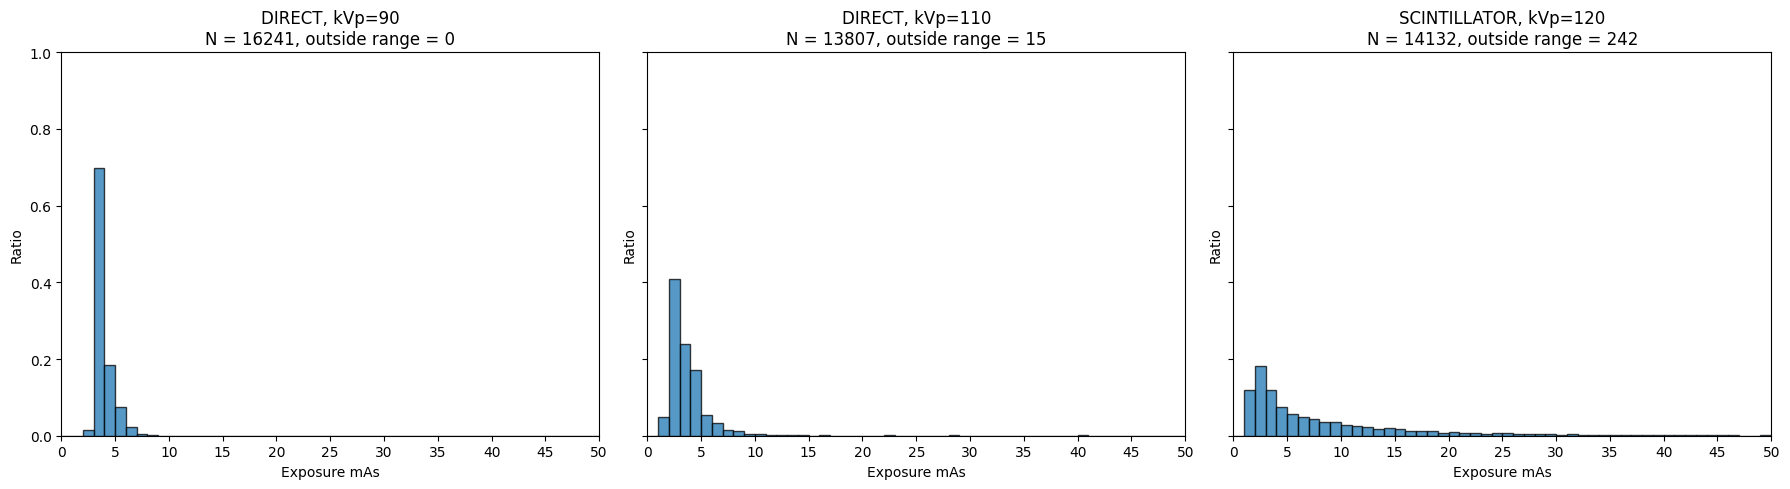

              population  mean_exposure_mas  std_exposure_mas
0         DIRECT, kVp=90               3.42              0.95
1        DIRECT, kVp=110               3.32              3.66
2  SCINTILLATOR, kVp=120               3.32              3.66


In [19]:
from utils.database_statistics import (
    get_exposure_mas_for_three_populations, 
    plot_exposure_mas_histograms_for_three_populations,
    population_mAs_statistics
    )

mas_df = get_exposure_mas_for_three_populations(settings.DB_name)


plot_exposure_mas_histograms_for_three_populations(
    mas_df,
    max_x=50,
)

population_mAs_statistics = population_mAs_statistics(mas_df)

print(population_mAs_statistics)


### PDF Report

In [20]:
from utils.database_reports import generate_aquisition_pdf_report
from pathlib import Path
import os

tables_for_report = {
    
    "View counts": view_counts,
    "Detector Types":detector_type_counts,
    "KVP by detector type - all views": kvp_detector_table,
    "KVP by detector type - AP view": kvp_detector_tables["AP"],
    "KVP by detector type - PA view": kvp_detector_tables["PA"],
    "KVP by detector type - Lateral view":kvp_by_detector_lateral,
    "KVP by detector type - LL view":kvp_by_detector_ll,
    "KVP by detector type - Missing view":kvp_by_detector_missing_view,
    "mAs Standard Deviation by Population": population_mAs_statistics
}

generate_aquisition_pdf_report(
    output_pdf_path=Path(os.path.join(
        "reports",
        "acquisition_statistics_report.pdf"
    )),
    tables=tables_for_report,
)


PDF report saved to: reports\acquisition_statistics_report.pdf


## mAs Statistics

In [ ]:
from utils.database_statistics import get_chexpert_population_statistics, print_chexpert_population_statistics

population_summary_df, label_statistics_df = get_chexpert_population_statistics(settings.DB_name)

print_chexpert_population_statistics(
    population_summary_df,
    label_statistics_df
)

### Generate Disease Report

In [ ]:
from utils.database_reports import generate_disease_aquisition_pdf_report
from pathlib import Path

generate_disease_aquisition_pdf_report(
    output_pdf_path=Path("reports/diagnostic_summary_report.pdf"),
    population_summary_df=population_summary_df,
    label_statistics_df=label_statistics_df,
)